# Draw Colormap for Height and Mean Curvature

**Date:** May 19, 2025  
**Author:** yying7@jh.edu  

---


## Mean Curvature Formula

Given a surface defined by a height function $ z = z(x, y) $, the mean curvature $ H $ at a point $ \mathbf{p}(x, y, z) $ is given by:

$$
H(\mathbf{p}(x, y, z)) = -\frac{(1 + z_x^2)z_{yy} + (1 + z_y^2)z_{xx} - 2z_x z_y z_{xy}}{2(1 + z_x^2 + z_y^2)^{3/2}}
$$

---

## Variable Definitions

- $z_x, z_y$: First partial derivatives of $ z $ with respect to $ x $ and $ y $
- $ z_{xx}, z_{yy}, z_{xy} $: Second partial derivatives
- $ \mathbf{p}(x, y, z) $: Point on the surface in 3D
- $ H $: Mean curvature, where:
  - $ H > 0 $: locally convex (bulging upward)
  - $ H < 0 $: locally concave (dipping downward)
  - $ H = 0 $: minimal surface (e.g., saddle point or flat)

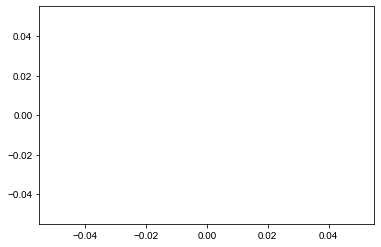

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import TwoSlopeNorm
import matplotlib
# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'
# Set global math and font config
matplotlib.rcParams["mathtext.fontset"] = "cm"      # Use Computer Modern for mathtext

# For easy styling, not required
# delete the following three lines if seaborn not installed
import seaborn as sns 
plt.plot()
sns.set_context("talk")

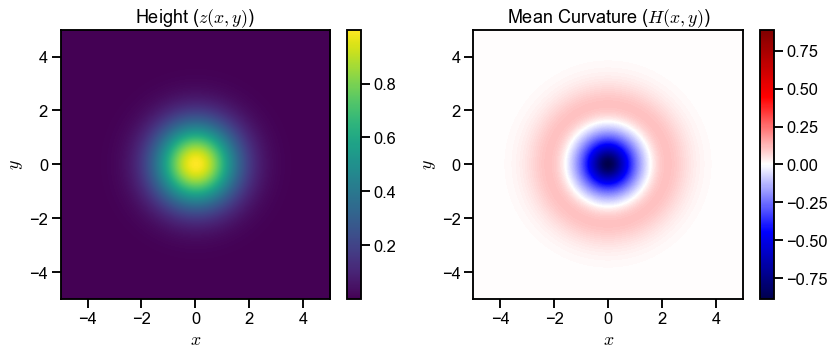

In [2]:
# Larger mesh domain for more flat region
x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x, y)

# Keep bump fixed in size by rescaling inside the exponent
Z = np.exp(-((X/1.5)**2 + (Y/1.5)**2))  # Gaussian bump

# Compute gradients
Zx, Zy = np.gradient(Z, x, y)
Zxx, Zxy = np.gradient(Zx, x, y)
Zyx, Zyy = np.gradient(Zy, x, y)

# First fundamental form coefficients
Fx = 1 + Zx**2
Fxy = Zx * Zy
Fy = 1 + Zy**2

# Second fundamental form coefficients
Sxx = Zxx
Sxy = Zxy
Syy = Zyy

# Mean curvature formula
numerator = (Fx * Syy + Fy * Sxx - 2 * Fxy * Sxy)
denominator = 2 * np.power(1 + Zx ** 2 + Zy ** 2, 1.5)
H = numerator / denominator

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Height heatmap
hmap1 = axs[0].imshow(Z, extent=[x.min(), x.max(), y.min(), y.max()],
                      origin='lower', cmap='viridis')
axs[0].set_title(r'Height ($z(x,y)$)')
axs[0].set_xlabel(r'$x$')
axs[0].set_ylabel(r'$y$')
fig.colorbar(hmap1, ax=axs[0], shrink = 0.972)

# Mean curvature heatmap with centered colormap
vmax = np.max(np.abs(H))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
hmap2 = axs[1].imshow(H, extent=[x.min(), x.max(), y.min(), y.max()],
                      origin='lower', cmap='seismic', norm=norm)
axs[1].set_title(r'Mean Curvature ($H(x,y)$)')
axs[1].set_xlabel(r'$x$')
axs[1].set_ylabel(r'$y$')
fig.colorbar(hmap2, ax=axs[1], shrink = 0.972)

plt.tight_layout()
plt.savefig("Colormap_height_mean_curv.svg", format = 'svg')
plt.show()